# AIM:
create evaluation workflow. Taking the manually extracted Ci impacts (validation set) and compare it with the CI impacts (llm_geolocations.ipynb) extrracted by the first LLM 1. 
As a first step the evaluation should be done only for the direct CI impacts - CI type, damage and geolocation

Issue:
* What is needed an approach that recognizes when an direct impact case is not detected by the model
Idea: 
* Split the original texts passed to the model on the exact chunks as again
* Then chunkwise check if the CI impacts from the validation set correspond in number and their textual similarity to the CI impacts infered by the LLM 1 and Entity Linking 

## Semantic Textual Similarity (STS)

Calculating the STS for both model configurations (chain of prompts, orchestration of models)
The outputs are cosine similarity scores for similar model outputs per chunk. They are ranked by score for each model, restricted to the top 20 results.  


In [11]:
import os
import sys
from pathlib import Path
import io
import gc
import time
import warnings
import subprocess
import importlib

from unidecode import unidecode
import langdetect
from fuzzywuzzy import fuzz
import torch
from huggingface_hub import login
import numpy as np
import spacy
import pandas as pd
import torch
import pyarrow as pa
import pyarrow.parquet as pq
import pickle
from matplotlib import pyplot as plt


# from utils.training import topic_search, topic_search_lm

sys.path.append('../')
from src.settings import settings as s
import src.document_cleaning as dc
import src.translation_model as tm


In [12]:
try: 
    login(token=os.getenv("HUGGINGFACE_TOKEN"))   # notebook_login
except:
    login(token=os.environ.get("HUGGINGFACE_TOKEN"))  # former HF_TOKEN



Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


### Direct CI impacts: LLM 1 vs domain-expertise 

In [50]:
#  Suppress future warnings from PyTorch
warnings.filterwarnings("ignore", category=FutureWarning)


#  Define data dir where tags.csv and domain-expertise derived tag lists are found 
VALID_DATA_FILENAME = "table_ci_impacts_sm.csv"
PATH_VALID_DATA = s.PATH_VALID_DATA
PATH_EVAL_RESULT = s.PATH_EVAL_RESULT
LLM_DATA_FILEPATH = Path(s.PATH_LLM_DATA / s.LLM_DATA_FILENAME) # "llm1_2026-02-11_7of9.csv" "llm_1_test_eval.csv"
SIMILARITY_LLM_FILENAME = s.SIMILARITY_LLM_FILENAME

df_valid = pd.read_csv(
    PATH_VALID_DATA / VALID_DATA_FILENAME,
    # usecols=["publication_id", "ci1_type", "ci1_damage", "ci1_location", "sentence_reference"]
)
print(len(df_valid))
## pre-process: 
# remove undone entries
df_valid = df_valid[~df_valid.astype(str).apply(lambda x: x.str.contains("xx")).any(axis=1)]
# remove further location info (e.g. that entry is a town, Landkreis, Bavaria etc.)
df_valid["ci1_location"] = df_valid["ci1_location"].replace(r"\s*\(.*\)", "", regex=True).str.strip()
df_valid = df_valid.dropna(subset=["publication_id"], how="all") # drop rows where citation info is missing
print(len(df_valid))



## prediction data
df_pred = pd.read_csv(
    LLM_DATA_FILEPATH,
    #usecols=["citation_id", "chunk_id", "infrastructure_type", "damage", "location", "chunk_text"]
)

df_pred 
## citation alignment
# print(df_pred["citation_id"])
# df_pred["citation_id"] = df_pred["citation_id"].map(dc.extract_citation_info) # FIXME as used with new funct returning author, year, title
# df_pred["citation_id"] = df_pred["citation_id"].apply(dc.extract_citation_info)
# print(df_pred["citation_id"])


142
134


,citation_id,chunk_id,infrastructure_type,damage,location,ci_entity,geo_entity,case_type,chunk_text
0,AEMET 2024,0,energy,severely damaged,Valencia,NaN,NaN,NaN,"STUDY ON THE SITUATION OF INTENSE, LOCALLY TORRENCIAL AND PERSISTENT LLUVIAS, IN THE IBERIC AND BALEARES PENINSULA BETWEEN OCTOBER 28 AND NOVEMBER 4, 2024 -Historical context of the event of October 29 in Valencia. Situation of intense rains in the Peninsula and the Balearic Islands between October 28 and November 4, 2024"
1,AEMET 2024,0,water,contaminated,Barcelona,NaN,NaN,NaN,"STUDY ON THE SITUATION OF INTENSE, LOCALLY TORRENCIAL AND PERSISTENT LLUVIAS, IN THE IBERIC AND BALEARES PENINSULA BETWEEN OCTOBER 28 AND NOVEMBER 4, 2024 -Historical context of the event of October 29 in Valencia. Situation of intense rains in the Peninsula and the Balearic Islands between October 28 and November 4, 2024"
2,AEMET 2024,0,transportation,blocked,Madrid,NaN,NaN,NaN,"STUDY ON THE SITUATION OF INTENSE, LOCALLY TORRENCIAL AND PERSISTENT LLUVIAS, IN THE IBERIC AND BALEARES PENINSULA BETWEEN OCTOBER 28 AND NOVEMBER 4, 2024 -Historical context of the event of October 29 in Valencia. Situation of intense rains in the Peninsula and the Balearic Islands between October 28 and November 4, 2024"
3,AEMET 2024,0,healthcare,largely destroyed,Granada,NaN,NaN,NaN,"STUDY ON THE SITUATION OF INTENSE, LOCALLY TORRENCIAL AND PERSISTENT LLUVIAS, IN THE IBERIC AND BALEARES PENINSULA BETWEEN OCTOBER 28 AND NOVEMBER 4, 2024 -Historical context of the event of October 29 in Valencia. Situation of intense rains in the Peninsula and the Balearic Islands between October 28 and November 4, 2024"
4,AEMET 2024,0,education,disrupted,Seville,NaN,NaN,NaN,"STUDY ON THE SITUATION OF INTENSE, LOCALLY TORRENCIAL AND PERSISTENT LLUVIAS, IN THE IBERIC AND BALEARES PENINSULA BETWEEN OCTOBER 28 AND NOVEMBER 4, 2024 -Historical context of the event of October 29 in Valencia. Situation of intense rains in the Peninsula and the Balearic Islands between October 28 and November 4, 2024"
...,...,...,...,...,...,...,...,...,...
3283,Krausmann 2014,342,healthcare,largely destroyed,East,NaN,NaN,NaN,"The severity of some of the analysed natural hazards was unexpected but many were not entirely unforeseen. Nevertheless, they caused a significant amount of damage and infrastructure service outage. This indicates an underestimation of the risk that resulted in siting in natural-hazard prone areas, insufficient design and a lack of preparedness. In order to avoid future disasters, the vulnerability of key critical infrastructures to natural hazards and the consequences of impact should be determined. Risk analysis is required to understan..."
3284,Krausmann 2014,342,education,heavily destroyed,West,NaN,NaN,NaN,"The severity of some of the analysed natural hazards was unexpected but many were not entirely unforeseen. Nevertheless, they caused a significant amount of damage and infrastructure service outage. This indicates an underestimation of the risk that resulted in siting in natural-hazard prone areas, insufficient design and a lack of preparedness. In order to avoid future disasters, the vulnerability of key critical infrastructures to natural hazards and the consequences of impact should be determined. Risk analysis is required to understan..."
3285,Krausmann 2014,343,energy,severely damaged,Luxembourg,NaN,NaN,NaN,"You can obtain their contact details by sending a fax to (352) 29 29-42758. EUR 27206 EN – Joint Research Centre – Institute for the Protection and Security of the Citizen Title: Report on lessons learned from recent catastrophic events Luxembourg: Publications Office of the European Union EUR – Scientific and Technical Research series – ISSN 1831-9424 As the Commission’s in-house science service, the Joint Research Centre’s mission is to provide EU policies with independent, evidence-based scientific and technical support throughout the whole policy cycle. Working in close cooperati..."
3286,Krausmann 2014,343,water,co

In [51]:
df_pred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3288 entries, 0 to 3287
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   citation_id          3288 non-null   object
 1   chunk_id             3288 non-null   int64 
 2   infrastructure_type  3288 non-null   object
 3   damage               3288 non-null   object
 4   location             3284 non-null   object
 5   ci_entity            23 non-null     object
 6   geo_entity           23 non-null     object
 7   case_type            23 non-null     object
 8   chunk_text           3288 non-null   object
dtypes: int64(1), object(8)
memory usage: 231.3+ KB


In [53]:
df_pred.loc[df_pred["citation_id"]== "Krausmann 2014"] # Krausmann -> large hallucinations when chunk-text is title or contact info (i.e when not about CI /impacts)

,citation_id,chunk_id,infrastructure_type,damage,location,ci_entity,geo_entity,case_type,chunk_text
1349,Krausmann 2014,0,energy,severely damaged,Luxembourg,NaN,NaN,NaN,"STREST – Report on lessons learned from recent catastrophic events Institute for the Protection and Security of the Citizen Address: Joint Research Centre, Via Enrico Fermi 2749, TP 186, 21027 Ispra (VA), Italy This publication is a Science and Policy Report by the Joint Research Centre, the European Commission’s in-house science service. It aims to provide evidence-based scientific support to the European policy-making process. The scientific output expressed does not imply a policy position of the European Commission. Neither the European Commission nor any person acting on behalf ..."
1350,Krausmann 2014,0,water,contaminated,Ports,NaN,NaN,NaN,"STREST – Report on lessons learned from recent catastrophic events Institute for the Protection and Security of the Citizen Address: Joint Research Centre, Via Enrico Fermi 2749, TP 186, 21027 Ispra (VA), Italy This publication is a Science and Policy Report by the Joint Research Centre, the European Commission’s in-house science service. It aims to provide evidence-based scientific support to the European policy-making process. The scientific output expressed does not imply a policy position of the European Commission. Neither the European Commission nor any person acting on behalf ..."
1351,Krausmann 2014,0,healthcare,disrupted,Industrial districts,NaN,NaN,NaN,"STREST – Report on lessons learned from recent catastrophic events Institute for the Protection and Security of the Citizen Address: Joint Research Centre, Via Enrico Fermi 2749, TP 186, 21027 Ispra (VA), Italy This publication is a Science and Policy Report by the Joint Research Centre, the European Commission’s in-house science service. It aims to provide evidence-based scientific support to the European policy-making process. The scientific output expressed does not imply a policy position of the European Commission. Neither the European Commission nor any person acting on behalf ..."
1352,Krausmann 2014,0,education,largely destroyed,Hydrocarbon pipelines,NaN,NaN,NaN,"STREST – Report on lessons learned from recent catastrophic events Institute for the Protection and Security of the Citizen Address: Joint Research Centre, Via Enrico Fermi 2749, TP 186, 21027 Ispra (VA), Italy This publication is a Science and Policy Report by the Joint Research Centre, the European Commission’s in-house science service. It aims to provide evidence-based scientific support to the European policy-making process. The scientific output expressed does not imply a policy position of the European Commission. Neither the European Commission nor any person acting on behalf ..."
1353,Krausmann 2014,0,IT,outages,Refineries,NaN,NaN,NaN,"STREST – Report on lessons learned from recent catastrophic events Institute for the Protection and Security of the Citizen Address: Joint Research Centre, Via Enrico Fermi 2749, TP 186, 21027 Ispra (VA), Italy This publication is a Science and Policy Report by the Joint Research Centre, the European Commission’s in-house science service. It aims to provide evidence-based scientific support to the European policy-making process. The scientific output expressed does not imply a policy position of the European Commission. Neither the European Commission nor any person acting on behalf ..."
...,...,...,...,...,...,...,...,...,...
3283,Krausmann 2014,342,healthcare,largely destroyed,East,NaN,NaN,NaN,"The severity of some of the analysed natural hazards was unexpected but many were not entirely unforeseen. Nevertheless, they caused a significant amount of damage and infrastructure service outage. This indicates an underestimation of the risk that resulted in siting in natural-hazard prone areas, insufficient design and a lack of preparedness. In order to avoid future disasters, the vulnerability of key critical infrastructures to natural hazards and the cons

In [17]:
df_pred.iloc[3284]["chunk_text"]

'The  severity  of  some  of  the  analysed  natural  hazards  was  unexpected  but  many were  not  entirely  unforeseen.  Nevertheless,  they  caused  a  significant  amount  of damage and infrastructure service outage. This indicates an underestimation of the risk  that  resulted  in  siting  in  natural-hazard  prone  areas,  insufficient  design  and  a lack  of  preparedness.  In  order  to  avoid  future  disasters,  the  vulnerability  of  key critical infrastructures to natural hazards and the consequences of impact should be determined.  Risk  analysis  is  required  to  understand  system  weaknesses  and  to prioritise  prevention  and  mitigation  measures.  This  should  be  coupled  with  a  cost-benefit  analysis.  This  risk  assessment  needs  to  be  based  on  the  realistic assessment  of  a  natural  hazard’s  severity  that  includes,  where  necessary,  climate-change projections.   Europe Direct is a service to help you find answers to your questions about the 

#### Load spaCy language model


In [19]:
# !uv run python -m spacy download en_core_web_lg

# os.chdir("/home/a-buch/Documents/TUB_DWN/_PROJECTS/CI-impacts-information-retrieval")
# nlp = spacy.load("en_core_web_lg")

In [20]:
## load english model with word vectors included
s.SPACY_MODEL = "en_core_web_lg"

print(f"Try loading spaCy language model ({s.SPACY_MODEL}) for remote instance (e.g., cluster)")
try: 
    nlp = spacy.load(s.SPACY_MODEL)
except (OSError, ValueError):
    print(f"spaCy language model '{s.SPACY_MODEL}' not found. Downloading ...")
    subprocess.check_call(["uv", "pip", "install", "spacy-transformers"])
    subprocess.check_call(["uv", "run", "python", "-m", "spacy", "download", s.SPACY_MODEL])
    nlp = spacy.load(s.SPACY_MODEL)
        

# !uv run python -m spacy download en_core_web_lg
# nlp = spacy.load("en_core_web_lg")


Try loading spaCy language model (en_core_web_lg) for remote instance (e.g., cluster)


In [21]:
def cosine_similarity(vector_a, vector_b):
    dot_product = np.dot(vector_a, vector_b)
    magnitude_a = np.linalg.norm(vector_a)
    magnitude_b = np.linalg.norm(vector_b)
    return dot_product / (magnitude_a * magnitude_b)


In [22]:
# ## unify citation column

# # get corresponding document from df_vald
# citation_pattern = r"(.*?)(\d{4})(.*)" # split at first occurrence of year
# # df_pred["publication_id"] = df_pred["citation"].map(dc.extract_citation_info)
# df_pred["citation"].map(dc.extract_citation_info)
# # df_pred = df_pred.rename({"citation": "publiation_id"})
# # df_pred.drop("citation", inplace=True)
# df_pred
# # try:
# #     authors, year, _ = re.findall(citation_pattern, filename)[0]
# #     citation = f"{authors} {year}"



#### Select records which have text references

In [23]:

print(len(df_pred), len(df_valid))
df_pred = df_pred[~df_pred["chunk_text"].isna()].reset_index(drop=True)
df_valid = df_valid[~df_valid["sentence_reference"].isna()].reset_index(drop=True)
print(len(df_pred), len(df_valid))


3288 136
3288 132


#### Translation of validation sentences

In [24]:

for entry in df_valid.itertuples():
    
    src_language = langdetect.detect(str(entry.sentence_reference))
    
    if src_language != "en":
        supported_languages = ["fr", "de", "es", "it", "itc", "nl"]
        if src_language not in supported_languages:
            print(f"Unsupported source language: {src_language}. Continue with original version of the sentence in validation set ")
            continue 

        print(f"\n ######## -------- Translating: {src_language} --> en -------- ######## \n")

        # clean up before applying translator
        gc.collect()
        torch.cuda.empty_cache()  # mainly after training needed, small effect when LLM applied only for inference
        torch.no_grad()
        
        # overwrite original sentence(s) with translated versions
        translated_sentence = tm.translate_2_english(src_language, str(entry.sentence_reference))
        df_valid.loc[df_valid.index[df_valid["sentence_reference"] == entry.sentence_reference], "sentence_reference"] = translated_sentence



 ######## -------- Translating: de --> en -------- ######## 

/home/a-buch/Documents/TUB_DWN/_PROJECTS/CI-impacts-information-retrieval/notebooks/huggingface_mirror/hub
Using device: cuda
Using locally saved model from /home/a-buch/Documents/TUB_DWN/_PROJECTS/CI-impacts-information-retrieval/notebooks/huggingface_mirror/hub


/home/a-buch/Documents/TUB_DWN/_PROJECTS/CI-impacts-information-retrieval/.venv/lib/python3.12/site-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Input document is a string (not DoclingObject). Wrapping it in a list for processing.
Continue with translation of text string
Source text:  Denn weil Brücken und Straßen in den braunen Wassermassen versanken, brachen die Logistikketten vieler Betriebe und setzten, weil Teile und Material fehlten, die Produktion matt. So stoppte Volkswagen Lastwagen stoppten vor zerstörten Brücken, Lastkähne konnten gar nicht erst
Translated text:  Because bridges and roads sank into the brown water masses, the logistics chains of many companies broke and, because parts and material were missing, set the production matt. Thus, Volkswagen trucks stopped from destroying bridges, load barges could not even stop at all.

 ######## -------- Translating: de --> en -------- ######## 

/home/a-buch/Documents/TUB_DWN/_PROJECTS/CI-impacts-information-retrieval/notebooks/huggingface_mirror/hub
Using device: cuda
Using locally saved model from /home/a-buch/Documents/TUB_DWN/_PROJECTS/CI-impacts-information-retriev

#### Postprocess (text cleaning)


In [25]:
# unicode to ascii representation

for col in ["infrastructure_type", "damage", "ci_entity", "geo_entity"]:
    df_pred[col] = df_pred[col].apply(lambda x: unidecode(x) if isinstance(x, str) else x) # hanlde potential np.nan


for col in ["ci1_type", "ci1_damage", "ci1_location"]:
    df_valid[col] = df_valid[col].apply(lambda x: unidecode(x) if isinstance(x, str) else x) # hanlde potential np.nan


#### Merge prediction entries with potential validation entries (nth:1 pairs)

In [30]:
print("Match chunk text of each prediction entry with related validiation entries (nth:1 pairs)") # getting nth:1 pairs

df_pred_valid_all = pd.DataFrame()
threshold = 85

# find for each prediction entry all validation entries for respective chunk 
# these validation entries are candidates from which the most similar one to the pred. entry is taken to calc. model recall 
# inlcduing also entries where pred_inof or valid_info is missing (e.g FNs, FPs)
for _, pred_entry in df_pred.iterrows():
    for _, valid_entry in df_valid.iterrows():  # all validation entries of all docs
        
        # Calculate match score by accounting for partial string matches. 
        # In detail, it calculates the similarity ratio using the shortest string (length n, here: "sentence_reference") against all n-length substrings of the larger string and returns the highest score 
        score = fuzz.partial_ratio(valid_entry['sentence_reference'], pred_entry['chunk_text'])

        if score >= threshold:
            entry_pred_valid = {
                "citation_id": pred_entry["citation_id"],
                "ci_pred": pred_entry["infrastructure_type"],
                "damage_pred": pred_entry["damage"],
                "location_pred": pred_entry["location"],
                "chunk_id_pred": pred_entry["chunk_id"],
                "chunk_text_pred": pred_entry["chunk_text"],
                "ci_valid": valid_entry["ci1_type"],
                "damage_valid": valid_entry["ci1_damage"],
                "location_valid": valid_entry["ci1_location"],
                "sentence_text_valid": valid_entry["sentence_reference"],
                "text_similarity": score
            }
            df_pred_valid_all = pd.concat([df_pred_valid_all, pd.DataFrame([entry_pred_valid])], ignore_index=True)  # n:1 relationship DF
        
        



Match chunk text of each prediction entry with related validiation entries (nth:1 pairs)


In [31]:
df_pred_valid_all.info() # 143 -190 entries

## --> FPs are more common compared to FNs, especially for predicting locations, 
# as it is easier to get a prep-valid match when pred.info is actually missing due to larger chunk-text (pred set) compared to sentence-text (valid set)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213 entries, 0 to 212
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   citation_id          213 non-null    object
 1   ci_pred              213 non-null    object
 2   damage_pred          213 non-null    object
 3   location_pred        213 non-null    object
 4   chunk_id_pred        213 non-null    int64 
 5   chunk_text_pred      213 non-null    object
 6   ci_valid             178 non-null    object
 7   damage_valid         163 non-null    object
 8   location_valid       146 non-null    object
 9   sentence_text_valid  213 non-null    object
 10  text_similarity      213 non-null    int64 
dtypes: int64(2), object(9)
memory usage: 18.4+ KB


In [45]:
pd.set_option('display.max_colwidth', 600)
df_pred_valid_all.iloc[[46, 42, 45, 43, 44, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140 , 198, 199, 200, 201, 202, 151]][["sentence_text_valid", "chunk_text_pred","text_similarity"]]

,sentence_text_valid,chunk_text_pred,text_similarity
46,"The event claimed 7 deaths in Germany, as of 07.06., the total number for all affected countries is 24.","The event has claimed 7 deaths in Germany, as of 07.06., the total number for all affected states is 24. At least 52,500 people are affected by evacuations in the Elbe and Danube catchment area.",93
42,"The event claimed 7 deaths in Germany, as of 07.06., the total number for all affected countries is 24.","The event has claimed 7 deaths in Germany, as of 07.06., the total number for all affected states is 24. At least 52,500 people are affected by evacuations in the Elbe and Danube catchment area.",93
45,"The event claimed 7 deaths in Germany, as of 07.06., the total number for all affected countries is 24.","The event has claimed 7 deaths in Germany, as of 07.06., the total number for all affected states is 24. At least 52,500 people are affected by evacuations in the Elbe and Danube catchment area.",93
43,"The event claimed 7 deaths in Germany, as of 07.06., the total number for all affected countries is 24.","The event has claimed 7 deaths in Germany, as of 07.06., the total number for all affected states is 24. At least 52,500 people are affected by evacuations in the Elbe and Danube catchment area.",93
44,"The event claimed 7 deaths in Germany, as of 07.06., the total number for all affected countries is 24.","The event has claimed 7 deaths in Germany, as of 07.06., the total number for all affected states is 24. At least 52,500 people are affected by evacuations in the Elbe and Danube catchment area.",93
122,"The evacuations in Saxony concerned about 26992, in Saxony-Anhalt about 11669 and Bavaria about 9600 people.","The following gives an overview of the people and animals affected by evacuation measures between May 31, 2013 and June 7, 2013. Most of the values represent lower barriers and are mainly taken from press releases in the respective districts. In Saxony, Saxony-Anhalt, Lower Saxony, Bavaria, Brandenburg and Baden-Württemberg, about 52549 people and 650 animals were affected by evacuations due to the flood situation on the Elbe, Danube and Mulde. The evacuations in Saxony affected about 26992, in Saxony-Anhalt about 11669 and Bavaria about 9600 people.",94
123,"The evacuations in Saxony concerned about 26992, in Saxony-Anhalt about 11669 and Bavaria about 9600 people.","The following gives an overview of the people and animals affected by evacuation measures between May 31, 2013 and June 7, 2013. Most of the values represent lower barriers and are mainly taken from press releases in the respective districts. In Saxony, Saxony-Anhalt, Lower Saxony, Bavaria, Brandenburg and Baden-Württemberg, about 52549 people and 650 animals were affected by evacuations due to the flood situation on the Elbe, Danube and Mulde. The evacuations in Saxony affected about 26992, in Saxony-Anhalt about 11669 and Bavaria about 9600 people.",94
124,"The evacuations in Saxony concerned about 26992, in Saxony-Anhalt about 11669 and Bavaria about 9600 people.","The following gives an overview of the people and animals affected by evacuation measures between May 31, 2013 and June 7, 2013. Most of the values represent lower barriers and are mainly taken from press releases in the respective districts. In Saxony, Saxony-Anhalt, Lower Saxony, Bavaria, Brandenburg and Baden-Württemberg, about 52549 people and 650 animals were affected by evacuations due to the flood situation on the Elbe, Danube and Mulde. The evacuations in Saxony affected about 26992, in Saxony-Anhalt about 11669 and Bavaria about 9600 people.",94
125,"In Saxony, Saxony-Anhalt, Lower Saxony, Bavaria, Brandenburg and Baden-Württemberg, about 52549 people and 650 animals were affected by evacuations due to the floods on the Elbe, Danube and Mulde.","The following gives an overview of the people and animals affected by evacuation measures between May 31, 2013 and June 7, 2013. Most of the values represent lower bar

In [38]:
# df_pred_valid_all.sort_values("text_similarity", ascending=True).head(50)  # 46, 42, 45, 43, 44, 122 -140 , 198-202, 151
df_pred_valid_all.iloc[[46, 42, 45, 43, 44, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140 , 198, 199, 200, 201, 202, 151]][["chunk_text_pred"]]

,chunk_text_pred
46,"The event has claimed 7 deaths in Germany, as ..."
42,"The event has claimed 7 deaths in Germany, as ..."
45,"The event has claimed 7 deaths in Germany, as ..."
43,"The event has claimed 7 deaths in Germany, as ..."
44,"The event has claimed 7 deaths in Germany, as ..."
122,The following gives an overview of the people ...
123,The following gives an overview of the people ...
124,The following gives an overview of the people ...
125,The following gives an overview of the people ...
126,The following gives an overview of the people ...


#### Calc similarities for all cases where text info in pred and valid set exists 


In [62]:
columns_valid = ["ci_valid", "damage_valid", "location_valid"]
columns_pred = ["ci_pred", "damage_pred", "location_pred"]



## AIM: 
print(" --- For each unique valid case (unique combi: [ci_valid, damage_valid, location_valid, sentence_text]) calculate similarity ---")
# remove all cases in df_pred_valid_all where pred_entities were wrongly assigned to a valid_entity
## ie keep only pre-valid pairs with highest similarity per unique valid case
for column_valid, column_pred in zip(columns_valid, columns_pred):

    df_pred_valid_smltry_all = pd.DataFrame()

    print(f"\n --------- Calculate similarities for entries in column pair: {column_pred} - {column_valid} ------------")


    ## calculate similarities
    for _, entry in df_pred_valid_all.iterrows():
        ## TODO calc FN and FP based on Belgian approach with self-set threshold which indicates when an entry pair is not similar
        ## TODO 2: calc also FP: i.e. when pred_info exists but not corresponding valid_info, and FNs (les FNs as wrong matches more likely due chunk-text is longer than sentence text)

        ## calc similarity when both pred_info and valid_info exist (ie. not NaN)
        if entry[column_pred] and entry[column_valid] is not np.nan:
            pred_impact = entry[column_pred]
            valid_impact = entry[column_valid]
            pred_vec = nlp(pred_impact).vector
            valid_vec = nlp(valid_impact).vector

            # calc. similarity by impact type (e.g. ci, damage, location) 
            if column_pred == "location_pred":
                similarity_score = fuzz.partial_ratio(pred_impact, valid_impact)
            else:
                # calculate cosine similarity for each pred-valid pair
                similarity_score = cosine_similarity(pred_vec, valid_vec)  # 0-1 value, the higher the more similar

            # store results
            dict_pair = {
                "impact_valid": valid_impact, 
                "impact_pred": pred_impact, 
                "impact_similarity": similarity_score,
                "tp_tn_fp_fn": "tp_tn",
                "citation": entry.citation_id,
                #"chunk_id_pred": entry.chunk_id,
                "chunk_text_pred": entry.chunk_text_pred,
                "sentence_text_valid": entry.sentence_text_valid,
                "identifier_valid": f"{entry.ci_valid}_{entry.damage_valid}_{entry.location_valid}", 
                }
            df_pred_valid_smltry_all = pd.concat([df_pred_valid_smltry_all, pd.DataFrame([dict_pair])], ignore_index=True)


    # when no similarity could be calculated
    entries_with_no_similarity = df_pred_valid_smltry_all.loc[df_pred_valid_smltry_all["impact_similarity"].isna()]
    print(f"Entries without similarity: {len(entries_with_no_similarity)}")
    print(entries_with_no_similarity[["impact_valid", "impact_pred", "impact_similarity", "citation"]])

    # for each unique valid_cols keep only pred-valid pairs of highest similarity
    try:
        df_pred_valid_smltry_all = df_pred_valid_smltry_all.groupby("identifier_valid").apply(lambda x: x.loc[x["impact_similarity"].idxmax()])
    except KeyError:
        print("Removing entries with missing similarity scores")
        df_pred_valid_smltry_all = df_pred_valid_smltry_all.dropna(subset=["impact_similarity"])
        df_pred_valid_smltry_all = df_pred_valid_smltry_all.groupby("identifier_valid").apply(lambda x: x.loc[x["impact_similarity"].idxmax()])
    

    print(f" ---------- Evaluation summary statistics: {column_pred}-----------")
    print(df_pred_valid_smltry_all.impact_similarity.describe())

    SIMILARITY_FILENAME = f"{column_pred.replace('_pred', '')}_{SIMILARITY_LLM_FILENAME}"
    SIMILARITY_FILEPATH = Path(PATH_EVAL_RESULT / SIMILARITY_FILENAME)


    print("Saving evaluation statistics, distribution plots, and scores to ", SIMILARITY_FILEPATH.stem, "[.parquet, _stats.json]")
    
    with open(SIMILARITY_FILEPATH, "w") as f:

        # results csv, parquet
        df_pred_valid_smltry_all.to_csv(SIMILARITY_FILEPATH.with_suffix('.csv'), index=False)
        df_pred_valid_smltry_all_pyarrow = pa.Table.from_pandas(df_pred_valid_smltry_all.astype( dtype="string[pyarrow]"))
        pq.write_table(df_pred_valid_smltry_all_pyarrow, SIMILARITY_FILEPATH.with_suffix(".parquet"))   

        #   summary statistics
        df_pred_valid_smltry_all_stats = df_pred_valid_smltry_all.describe()
        f = SIMILARITY_FILEPATH.parent / f"{SIMILARITY_FILEPATH.stem}_stats.json"  
        df_pred_valid_smltry_all_stats.to_json(f, indent=4)
        
        # distribution plots
        df_pred_valid_smltry_all.impact_similarity.hist(bins=100)
        plt.savefig(SIMILARITY_FILEPATH.parent / f"{SIMILARITY_FILEPATH.stem}_hist.png")
        plt.close()





 --- For each unique valid case (unique combi: [ci_valid, damage_valid, location_valid, sentence_text]) calculate similarity ---

 --------- Calculate similarities for entries in column pair: ci_pred - ci_valid ------------
Entries without similarity: 0
Empty DataFrame
Columns: [impact_valid, impact_pred, impact_similarity, citation]
Index: []
 ---------- Evaluation summary statistics: ci_pred-----------
count    20.000000
mean      0.683951
std       0.207147
min       0.375634
25%       0.507682
50%       0.616437
75%       0.798087
max       1.000000
Name: impact_similarity, dtype: float64
Saving evaluation statistics, distribution plots, and scores to  ci_smlrty_llm_1_updprompt [.parquet, _stats.json]

 --------- Calculate similarities for entries in column pair: damage_pred - damage_valid ------------
Entries without similarity: 0
Empty DataFrame
Columns: [impact_valid, impact_pred, impact_similarity, citation]
Index: []
 ---------- Evaluation summary statistics: damage_pred------

### Analyse evaluation results 


In [65]:
df_pred_valid_smltry_all#.info()

,impact_valid,impact_pred,impact_similarity,tp_tn_fp_fn,citation,chunk_text_pred,sentence_text_valid,identifier_valid
identifier_valid,,,,,,,,
Airport terminal_damaged_Catania Airport,Catania Airport,Catania,100,tp_tn,Ferlita 2023,"Damages for more than 80 million euros to the airport of Catania Further damages occurred a few days ago at the airport of Catania considered the fifth by order of importance throughout Italy. Following a fire flared inside the terminals, the access areas were promptly closed to the travellers creating a huge damage to the economy of the territory, the tourism sector and various professionals. In monetary terms, the damages are huge: the National Civil Aviation Authority calculates a total investment for plants and maintenances of about 200 thousand euros. The Mec (Movement of voters consu...","Further damage occurred a few days ago at the airport of Catania considered the fifth by order of importance throughout Italy. Following a fire flared up inside the terminals, the access areas were promptly closed to the travelers creating a huge damage to the economy of the territory, the tourist industry and various professionals.",Airport terminal_damaged_Catania Airport
Airport_affected_Catania Airport,Catania Airport,Catania,100,tp_tn,Ferlita 2023,"of euro per day due to the closing of the port of call due to the fire. The total of the damages, would amount to more than 80 million euros. The fire happened last Sunday night at the airport Vincenzo Bellini of Catania and, after two days of incessant work for the shutdown of the fire, from the terminal C are resumed arrivals and departures. In the meantime, the men of the Nia(Nucleo fire investigation) enter into action to establish the causes of the fire even if it is assumed a short circuit occurred in the conditioning system. It is not excluded also the track of the arson fire. The F...","The total of the damages, would amount to more than 80 million euros. The fire happened last Sunday night at the airport Vincenzo Bellini of Catania and, after two days of continuous work for the shutdown of the fire, from terminal C are resumed arrivals and departures.",Airport_affected_Catania Airport
High-speed train_derailed_Near Malaga,Near Malaga,Malaga,100,tp_tn,Gilbody Dickerson 2024,"Jon Clarke, editor of news outlet The Olive Press, told Sky News from oneof the worst affected areas in Malaga that he expected more deaths tobe announced.He said the storms were ""the worst natural disaster at least for 50 years"".Mr Clarke said some areas in the Valencia region were hit by ""half a year'srain"" in six to seven hours.Dog and woman rescued from deadly floodsTransport was also severely affected, with a high-speed train with almost300 people on board derailed near Malaga. Authorities said no one washurt.Rail lines elsewhere were also disrupted.Spain's transport ministry announce...","Transport was also severely affected, with a high-speed train with almost300 people on board derailed near Malaga.",High-speed train_derailed_Near Malaga
Port infrastructure_affected_Port of Valencia,Port of Valencia,Valencia,100,tp_tn,Containerlift 2024,"Valencia Port Resumes Operations Following Devastating Flooding in Spain -Containerlift.co.uk -Transport/Lifting/Ship… Valencia Port Resumes Operations Following Devastating Flooding in Spain Valencia Port Resumes Operations Following Devastating Flooding in Spain -Containerlift.co.uk -Transport/Lifting/Ship… The Port of Valencia has reopened for operations after severe flooding temporarily halted activity across eastern Spain. Key terminals, including CSP Iberian Valencia Terminal, MSC Terminal Valencia, and APM Terminals, resumed receiving and dispatching goods on October 30, bringing re...",The Port of Valencia has reopened for operations after severe flooding temporarily halted activity across eastern Spain.,Port infrastructure_affected_Port of Valencia
Port infrastructure_affected_Sagunto port,Sagunto port,Sagunto,100,tp_tn,Contain

In [211]:
## find out for which docs model performed bad (or good)
## based on this info try to improve model 

df_pred_valid_smltry_all.dropna(subset=["impact_similarity"]).groupby("citation").apply(lambda x: x.loc[x["impact_similarity"].idxmax()]).sort_values(by="impact_similarity", ascending=True)
## check EFE, Wilson, European Investment Bank, Containerlift, Lloyds List, Gilbody Dickerson


,impact_valid,impact_pred,impact_similarity,tp_tn_fp_fn,citation,chunk_text_pred,sentence_text_valid,identifier_valid
citation,,,,,,,,
Khazai 2013,affected,flooded,0.424709,tp_tn,Khazai 2013,"In Table 3, the districts with the highest num...","Also in several sections, the Bundesautobahn A...",roads_affected_Berchtesgadener Land
ABC 2024,affected,localized flooding,0.601925,tp_tn,ABC 2024,Heavy rains and a severe thunderstorm brought ...,Heavy rains and a severe thunderstorm brought ...,airport_affected_Malaga area
Containerlift 2024,affected,severely damaged,0.677238,tp_tn,Containerlift 2024,Valencia Port Resumes Operations Following Dev...,The Port of Valencia has reopened for operatio...,Port infrastructure_affected_Port of Valencia
Lloyd's List 2024,limited usable,limited access,0.762635,tp_tn,Lloyd's List 2024,"following the floods, which have claimed the l...",Road access to the terminals remains limited.,access roads to port terminals_limited usable_...
Ferlita 2023,damaged,severely damaged,0.906963,tp_tn,Ferlita 2023,Damages for more than 80 million euros to the ...,Further damage occurred a few days ago at the ...,Airport terminal_damaged_Catania Airport
Wilson 2024,disrupted,disrupted,1.000000,tp_tn,Wilson 2024,"BARCELONA, Spain (AP) — Several people were re...",The high-speed train service between Valencia ...,railway_disrupted_High-speed service between V...
Karakatsani 2023,destroyed,destroyed,1.000000,tp_tn,Karakatsani 2023,The economic impact of the recent devastating ...,"National roads were closed, bridges colla...",bridges_destroyed_nan
Gilbody Dickerson 2024,derailed,derailed,1.000000,tp_tn,Gilbody Dickerson 2024,"Jon Clarke, editor of news outlet The Olive Pr...","Transport was also severely affected, with a h...",High-speed train_derailed_Near Malaga
Kaur 2025,outages,outages,1.000000,tp_tn,Kaur 2025,Damage assessments indicate that at least 12 h...,Power outages were reported across Pisak and p...,electricity infrastructure_outages_Marusici


In [218]:
## check entries of worst performace docs for damage
df_pred_valid_smltry_all.loc[df_pred_valid_smltry_all["citation"].isin(["Khazai 2023", "ABC 2024", "Containerlift 2024", "Lloyds List 2024", "Ferlita 2023"])]

,impact_valid,impact_pred,impact_similarity,tp_tn_fp_fn,citation,chunk_text_pred,sentence_text_valid,identifier_valid
identifier_valid,,,,,,,,
Airport terminal_damaged_Catania Airport,damaged,severely damaged,0.906963,tp_tn,Ferlita 2023,Damages for more than 80 million euros to the ...,Further damage occurred a few days ago at the ...,Airport terminal_damaged_Catania Airport
Airport_affected_Catania Airport,affected,severely damaged,0.677238,tp_tn,Ferlita 2023,of euro per day due to the closing of the port...,"The total of the damages, would amount to more...",Airport_affected_Catania Airport
Port infrastructure_affected_Port of Valencia,affected,severely damaged,0.677238,tp_tn,Containerlift 2024,Valencia Port Resumes Operations Following Dev...,The Port of Valencia has reopened for operatio...,Port infrastructure_affected_Port of Valencia
Port infrastructure_affected_Sagunto port,affected,severely damaged,0.677238,tp_tn,Containerlift 2024,"In an advisory, shipping company Hapag-Lloyd n...","Nevertheless, the reopening of Valencia and Sa...",Port infrastructure_affected_Sagunto port
airport_affected_Malaga area,affected,localized flooding,0.601925,tp_tn,ABC 2024,Heavy rains and a severe thunderstorm brought ...,Heavy rains and a severe thunderstorm brought ...,airport_affected_Malaga area
highway_affected_State highway 113 in Partinico area,affected,threatened several homes,0.555567,tp_tn,Ferlita 2023,"""Bonifato"" has been almost destroyed due to th...",Also the territory of Partinico was not spared...,highway_affected_State highway 113 in Partinic...
road_affected_provincial road 63 in Partinico area,affected,threatened several homes,0.555567,tp_tn,Ferlita 2023,"""Bonifato"" has been almost destroyed due to th...",Flames also on the provincial road 63 that con...,road_affected_provincial road 63 in Partinico ...


In [ ]:
## check entries of worst performance docs for Ci tyes
df_pred_valid_smltry_all.loc[df_pred_valid_smltry_all["citation"].isin(["EFE 2024", "Containerlift 2024", "Lloyds List 2024", "Wilson 2024", "Gilbody Dickerson 2024", "European Investment Bank 2025"])].head(50)


## For each validation entry, search for all prediction cases of the same chunk 

In [ ]:
## get same impact entries
columns_valid = ["ci1_type", "ci1_damage", "ci1_location"]
columns_pred = ["infrastructure_type", "damage", "location"]


for column_valid, column_pred in zip(columns_valid, columns_pred):

    print(f" --------- Processing column pair: {column_valid} - {column_pred} ------------")
    
    df_valid_pred_all = pd.DataFrame()
    citations_list = []

    ## for each validation record
    for i in range(len(df_valid)):
        
        highest_similarity_score = 0.00
        
        ## needed to traceback info when entry is missing in pred. DS
        # chunk_id_value_valid = df_valid.chunk_id[i]

        # select nth validation record and check that it has value
        df_valid_entry = df_valid.iloc[i]
        if df_valid_entry[column_valid] is np.nan:
            continue
        
        citation_str = df_valid_entry.publication_id
        citations_list.append(citation_str)


        # get all corresponding prediction records
        df_pred_entries = df_pred[df_pred["citation_id"].isin([citation_str])]

        #  handle on NANs
        df_pred_entries[column_pred] = np.where(df_pred_entries[column_pred].isna(), "nan", df_pred_entries[column_pred])
        # df_pred_entries[column_pred] = df_pred_entries[column_pred].astype(str)
        # remove double whitespaces
        # df_pred_doc[column_pred] = df_pred_doc[column_pred].replace("  ", " ")
        # df_valid_entries[column_valid] = df_valid_entries[column_valid].replace("  ", " ")


        # vector of validiation entry 
        valid_impact = df_valid_entry[column_valid]
        valid_vec = nlp(valid_impact).vector

        # print(" ------- Searching for citation:", citation_str, " in predictions ------- ")

        # Compute similarity between each validation CI impact case and all potential predicted CI impact cases (cross-product)
        for j in range(len(df_pred_entries[column_pred])):

            if df_pred_entries[column_pred].iloc[j] == "nan":
                continue

            pred_impact = df_pred_entries[column_pred].iloc[j]

            pred_vec = nlp(pred_impact).vector
            similarity_score = cosine_similarity(valid_vec, pred_vec)  # 0-1 value, the higher the more similar
            # print(f"Similarity {i}-{j}: {similarity_score}")

            # print(f"Searching for highest similarity ... ")
            ## get only pair with highest similarity
            if similarity_score > highest_similarity_score:
                
                highest_similarity_score = similarity_score
                
                dict_pair = {
                    "impact_valid": valid_impact, 
                    "impact_pred": pred_impact, 
                    "similarity": highest_similarity_score,
                    "citation": citation_str,
                    "chunk_id_pred": (df_pred.chunk_id[i],  df_pred.chunk_id[j])
                }
            else:
                continue

        df_valid_pred_all = pd.concat([df_valid_pred_all, pd.DataFrame([dict_pair])], ignore_index=True)


    print(f" ---------- Evaluation summary statistics - {column_pred}: -----------")
    print(df_valid_pred_all.similarity.describe())

    

    SIMILARITY_FILENAME = f'{column_pred}_{SIMILARITY_LLM_FILENAME}'
    SIMILARITY_FILEPATH = Path(PATH_EVAL_RESULT / SIMILARITY_FILENAME)

    print("Saving evaluation statistics, distribution plots, and scores to ", SIMILARITY_FILEPATH.stem, "[.parquet, _stats.json]")
    with open(SIMILARITY_FILEPATH, 'w') as f:
        # results
        df_valid_pred_all.to_csv(SIMILARITY_FILEPATH.with_suffix('.csv'), index=False)
        df_valid_pred_all_pyarrow = pa.Table.from_pandas(df_valid_pred_all)
        pq.write_table(df_valid_pred_all_pyarrow, SIMILARITY_FILEPATH)   
        #   summary statistics
        df_valid_pred_all_stats = df_valid_pred_all.describe()
        f = SIMILARITY_FILEPATH.parent / f"{SIMILARITY_FILEPATH.stem}_stats.json"  
        df_valid_pred_all_stats.to_json(f, indent=4)
        # distribution plots
        df_valid_pred_all.similarity.hist(bins=100).to_file(SIMILARITY_FILEPATH.parent / f"{SIMILARITY_FILEPATH.stem}_hist.png")



    # similarity_threshold = 0.75
    # df_valid_pred_all['is_similar'] = df_valid_pred_all['similarity'] <= similarity_threshold
    # print(f"Number of similar impact cases (similarity >= {similarity_threshold}): {df_valid_pred_all['is_similar'].sum()} out of {len(df_valid_pred_all)}\n")

    # df_valid_pred_all =  df_valid_pred_all[df_valid_pred_all['similarity'] <= similarity_threshold]

    # SIMILARITY_FILENAME = f'{column_pred}_lower75_{SIMILARITY_LLM_FILENAME}'
    # SIMILARITY_FILEPATH = Path(PATH_EVAL_RESULT / SIMILARITY_FILENAME)

    # with open(SIMILARITY_FILEPATH, 'w') as f:
    #     # results
    #     df_valid_pred_all.to_csv(SIMILARITY_FILEPATH.with_suffix('.csv'), index=False)
    #     df_valid_pred_all_pyarrow = pa.Table.from_pandas(df_valid_pred_all)
    #     pq.write_table(df_valid_pred_all_pyarrow, SIMILARITY_FILEPATH)  
    #     #   summary statistics
    #     df_valid_pred_all_stats = df_valid_pred_all.describe()
    #     f = SIMILARITY_FILEPATH.parent / f"{SIMILARITY_FILEPATH.stem}_stats.json"  
    #     df_valid_pred_all_stats.to_json(f, indent=4)


 --------- Processing column pair: ci1_type - infrastructure_type ------------


/tmp/ipykernel_32745/2878094738.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pred_entries[column_pred] = np.where(df_pred_entries[column_pred].isna(), "nan", df_pred_entries[column_pred])
/tmp/ipykernel_32745/2640203756.py:5: RuntimeWarning: invalid value encountered in scalar divide
  return dot_product / (magnitude_a * magnitude_b)


 ---------- Evaluation summary statistics - infrastructure_type: -----------
count    106.000000
mean       0.800988
std        0.165914
min        0.544855
25%        0.600174
50%        0.791639
75%        1.000000
max        1.000000
Name: similarity, dtype: float64


<Axes: >

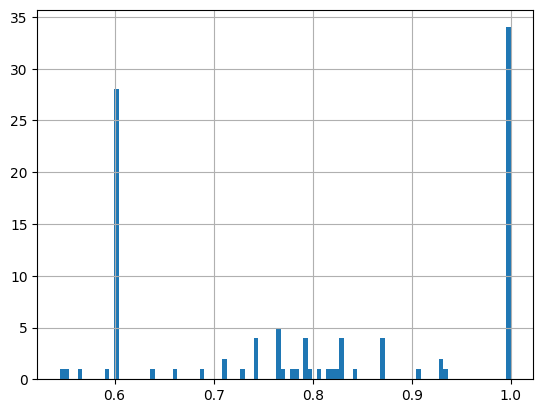

In [ ]:
# df_valid_pred_all[df_valid_pred_all['similarity'] <= 0.75]

# df_valid_pred_all.similarity.hist(bins=100)

In [81]:
columns_pred

['infrastructure_type', 'damage', 'location']

In [35]:
LLM_DATA_FILEPATH

PosixPath('../data/llm_outputs/llm1_2026-02-11_7of9_old.csv')

### Load parquet file

In [22]:

columns_pred = ["infrastructure_type", "damage", "location"]

In [ ]:
column_pred = "infrastructure_type"
SIMILARITY_FILENAME = f'llm1_similarity_{column_pred}_75.parquet'
SIMILARITY_FILEPATH = Path(PATH_EVAL_RESULT / SIMILARITY_FILENAME)

with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    df = pd.read_parquet(SIMILARITY_FILEPATH, engine='pyarrow')
    display(df)

## Archive

In [ ]:
## Aim 
## for all identical valid entries ie. with same [ci_valid	damage_valid	location_valid	sentence_text_valid]
## get the match to pred_entity with highest similarity

In [ ]:
    # ## calc for each entry with the same chunk_text the similarity between valid_impact and pred_impact
    # ## means we calc also the False Negatives (ie. where valid entry exists but no prediction)


    # # iterate over groups of entities which refer to the same valid case (i.e. which are identical in valid_columns)
    # # TODO iterate over unqiue cases in df_valid (instead of using grouper)
    # grouper = df_pred_valid_all[["ci_valid", "damage_valid", "location_valid", "sentence_text_valid"]].drop_duplicates()
    # for group in grouper.itertuples():
    #     df_pred_valid_group = df_pred_valid_all[df_pred_valid_all[["ci_valid", "damage_valid", "location_valid", "sentence_text_valid"]] == group[["ci_valid", "damage_valid", "location_valid", "sentence_text_valid"]]]

    #     # calc. similarities to pred_entities
    #     for i, entry in df_pred_valid_group.iterrows():

    #         highest_similarity_score = 0 

    #         if entry[column_pred].iloc[i] == "nan":
    #             continue
            
    #         # calc embeddings
    #         pred_impact = entry[column_pred].iloc[i]
    #         pred_vec = nlp(pred_impact).vector

    #         valid_impact = entry[column_valid].iloc[i] # is unique for each group
    #         valid_vec = nlp(valid_impact).vector
    #         print(valid_impact, "valid_impact")
            
    #         similarity_score = cosine_similarity(valid_vec, pred_vec)  # 0-1 value, the higher the more similar
    #         # print(f"Similarity {i}-{j}: {similarity_score}")

    #         ## return only pred-valid-pair with highest similarity
    #         if similarity_score > highest_similarity_score:
                
    #             highest_similarity_score = similarity_score
                
    #             entry["impact_similarity"] = highest_similarity_score

    # ## FNs
    # # # calc FN when valid_info exists but not corresponding pred_info
    # ## number of FNs is small due that wrong matching with any chunk-text is more likely due to its text size comapred sentence-level (valid set) 
    # elif entry[column_pred] is np.nan:
    #     similarity_score = 0
    #     dict_pair = {
    #         "impact_valid": valid_impact, 
    #         "impact_pred": pred_impact, 
    #         "impact_similarity": similarity_score,
    #         "tp_tn_fp_fn": "fn",
    #         "citation": entry.citation_id,
    #         "chunk_text_pred": entry.chunk_text_pred,
    #         "sentence_text_valid": entry.sentence_text_valid,
    #         }
    #     df_pred_valid_smltry_all = pd.concat([df_pred_valid_smltry_all, pd.DataFrame([dict_pair])], ignore_index=True)

    # ## FPs
    # elif entry[column_valid] is np.nan:
    #     similarity_score = 0
    #     dict_pair = {
    #         "impact_valid": valid_impact, 
    #         "impact_pred": pred_impact, 
    #         "impact_similarity": similarity_score,
    #         "tp_tn_fp_fn": "fp",
    #         "citation": entry.citation_id,
    #         "chunk_text_pred": entry.chunk_text_pred,
    #         "sentence_text_valid": entry.sentence_text_valid,
    #         }
    #     df_pred_valid_smltry_all = pd.concat([df_pred_valid_smltry_all, pd.DataFrame([dict_pair])], ignore_index=True)




In [ ]:
# ## get same impact entries
# columns_valid = ["ci1_type", "ci1_damage", "ci1_location"]
# columns_pred = ["infrastructure_type", "damage", "location"]



## iterate over predictions and search for each prediction reocrds for corresponding valid cases 

# for column_valid, column_pred in zip(columns_valid, columns_pred):

#     print(f" --------- Processing column pair: {column_valid} - {column_pred} ------------")
    
#     df_valid_pred_all = pd.DataFrame()
#     citations_list = []

#     ## for each validation record
#     for i in range(len(df_valid)):
        
#         highest_similarity_score = 0.00
        
#         ## needed to traceback info when entry is missing in pred. DS
#         # chunk_id_value_valid = df_valid.chunk_id[i]

#         # select nth validation record
#         df_valid_entry = df_valid.iloc[i]
#         citation_str = df_valid_entry.publication_id
#         citations_list.append(citation_str)
#         print(" ------- Searching for citation:", citation_str, " in predictions ------- ")


#         # get all corresponding prediction records
#         df_pred_entries = df_pred[df_pred["citation_id"].isin([citation_str])]
#         #  handle on NANs
#         df_pred_entries[column_pred] = np.where(df_pred_entries[column_pred].isna(), "nan", df_pred_entries[column_pred])
#         # df_pred_entries[column_pred] = df_pred_entries[column_pred].astype(str)
#         # remove double whitespaces
#         # df_pred_doc[column_pred] = df_pred_doc[column_pred].replace("  ", " ")
#         # df_valid_entries[column_valid] = df_valid_entries[column_valid].replace("  ", " ")

#         # skip when validation entry ha no value
#         if df_valid_entry[column_valid] is np.nan:
#             continue

#         # vector of validiation entry 
#         valid_impact = df_valid_entry[column_valid]
#         valid_vec = nlp(valid_impact).vector


#         # Compute similarity between each predicted impact case and all potential validation impact cases (cross-product)
#         # print(f"Searching for highest similarity of`{pred_impact}` in validation set ... ")
#         for j in range(len(df_pred_entries[column_pred])):

#             if df_pred_entries[column_pred].iloc[j] == "nan":
#                 continue

#             pred_impact = df_pred_entries[column_pred].iloc[j]

#             pred_vec = nlp(pred_impact).vector
#             similarity_score = cosine_similarity(valid_vec, pred_vec)  # 0-1 value, the higher the more similar
#             # print(f"Similarity {i}-{j}: {similarity_score}")

#             ## get only pair with highest similarity
#             if similarity_score > highest_similarity_score:
                
#                 highest_similarity_score = similarity_score
                
#                 dict_pair = {
#                     "impact_valid": valid_impact, 
#                     "impact_pred": pred_impact, 
#                     "similarity": highest_similarity_score,
#                     "citation": citation_str,
#                     "chunk_id_pred": df_pred.chunk_id[i]
#                 }
#             else:
#                 continue

#         df_valid_pred_all = pd.concat([df_valid_pred_all, pd.DataFrame([dict_pair])], ignore_index=True)


#     print(" ---------- Evaluation summary statistics: -----------")
#     print(df_valid_pred_all.similarity.describe())



#     SIMILARITY_FILENAME = f'{SIMILARITY_LLM_FILENAME}_{column_pred}.parquet'
#     SIMILARITY_FILEPATH = Path(PATH_EVAL_RESULT / SIMILARITY_FILENAME)

#     print("Saving evaluation statistics and scores to ", SIMILARITY_FILEPATH.stem, "[.parquet, _stats.json]")
#     with open(SIMILARITY_FILEPATH, 'w') as f:
#         # results
#         df_valid_pred_all_pyarrow = pa.Table.from_pandas(df_valid_pred_all)
#         pq.write_table(df_valid_pred_all_pyarrow, SIMILARITY_FILEPATH)   
#         #   summary statistics
#         df_valid_pred_all_stats = df_valid_pred_all.describe()
#         f = SIMILARITY_FILEPATH.parent / f"{SIMILARITY_FILEPATH.stem}_stats.json"  
#         df_valid_pred_all_stats.to_json(f, indent=4)



#     similarity_threshold = 0.75
#     df_valid_pred_all['is_similar'] = df_valid_pred_all['similarity'] >= similarity_threshold
#     print(f"Number of similar impact cases (similarity >= {similarity_threshold}): {df_valid_pred_all['is_similar'].sum()} out of {len(df_valid_pred_all)}")

#     SIMILARITY_FILENAME = f'{SIMILARITY_LLM_FILENAME}_{column_pred}_75.parquet'
#     SIMILARITY_FILEPATH = Path(PATH_EVAL_RESULT / SIMILARITY_FILENAME)

#     with open(SIMILARITY_FILEPATH, 'w') as f:
#         # results
#         df_valid_pred_all_pyarrow = pa.Table.from_pandas(df_valid_pred_all)
#         pq.write_table(df_valid_pred_all_pyarrow, SIMILARITY_FILEPATH)  
#         #   summary statistics
#         df_valid_pred_all_stats = df_valid_pred_all.describe()
#         f = SIMILARITY_FILEPATH.parent / f"{SIMILARITY_FILEPATH.stem}_stats.json"  
#         df_valid_pred_all_stats.to_json(f, indent=4)


In [ ]:

# #  Define folder for handling and writing outputs
# def write_to_file(data, out_folder, filename):
#     """Convert output to DataFrame and write to file"""
#     df = pd.DataFrame(list(data), columns=['tag', 'sts_score'])
#     #  Sort the DataFrame by similarity (explicitly)
#     df = df.sort_values(by='sts_score', ascending=False)
#     #  Assign integers to ranking
#     df['rank'] = df['sts_score'].rank(method='first', ascending=False).astype(int)
#     #  Only keep the first 20 resulting tags
#     df = df.head(50)
#     #  Save to file
#     df.to_csv(out_folder / f'{filename}_output.csv', index=False)

# #  Fill run metrics to dictionary
# def handle_metrics(metrics, model_name, length, end_time, start_time):
#     print(f'-> Took {end_time - start_time:.2f} seconds. Number of tags: {length}.')
#     metrics.append({
#         'modelname': model_name,
#         'runtime': round(end_time - start_time, 2),
#         'tagcount': length
#     })
#     return metrics

# class CPU_Unpickler(pickle.Unpickler):
#     """Fix for having issues with loading models on CPU"""
#     def find_class(self, module, name):
#         if module == 'torch.storage' and name == '_load_from_bytes':
#             return lambda b: torch.load(io.BytesIO(b), map_location='cpu')
#         else: return super().find_class(module, name)
